# ST-ResNet: memory-conscious hotspot and OD forecasting
Adapted from your supplied **ST_ResNet_Complete_Implementation_Guide (1).md**, using its Urban Flow path (not TaxiBJ/BikeNYC).

**Start with a fresh Colab GPU runtime.** Run cells in order. In Cell 2, set your CSV/Parquet paths. Cell 3 scans the files in chunks and shows their observed dates. Then enter the verified coverage dates in Cell 4; dates cannot be invented from the guide.

This notebook reduces **system RAM** and **GPU VRAM** separately:

| Area | Implementation |
|---|---|
| Raw trips | Only five necessary columns, 25,000 rows per chunk; no full-file DataFrame |
| Aggregation | Sparse SQLite counts on local disk, bounded cache |
| Training data | Fixed-size hourly records on disk; reads only requested hours, no expanded lag arrays |
| GPU | OD batch 1, hotspot batch 4, CUDA mixed precision, sequential models |
| Model capacity | 16 hidden channels and 2 residual blocks per branch by default; guide used 64 and 4 |
| Evaluation | Batchwise totals; no collection of all predictions |
| Recovery | Atomic best/last checkpoints, completed-epoch resume, optional Drive checkpoint directory |

Closeness / daily / weekly branches, pre-activation BatchNorm residual blocks, learnable fusion, calendar network, tanh, training-only min/max scaling, Adam and scaled RMSE remain. Smaller capacity and batches can change accuracy; compare validation performance. This is designed to lower memory use, **not a guarantee for every GPU or dataset**. Raw trip data was not attached, so no real-data training result is claimed.

Targets retain the guide's definitions: hotspot channels = **drop-offs, pickups**; OD = **trips completed in each hour**, with positive duration and non-voided payment. Historical departure-hour OD is exported separately. Zone indices are not geographic coordinates. No trips are sampled and no top-zone subset is imposed.


## Cell 1 — Dependencies and memory monitor
Colab normally includes PyTorch. This installs only missing packages and does not replace an existing torch/CUDA installation. CPU mode works for debugging but full OD training can be slow.


In [1]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount("/content/drive")

# Replace with the actual path to your preprocessed CSV file
DATA_PATH = "/content/drive/MyDrive/DATATHON/Train/train_cleaned.csv"
DATA_PATH_TEST = "/content/drive/MyDrive/DATATHON/Test/test_cleaned.csv"
# Load the dataset
df = pd.read_csv(DATA_PATH)



display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,provider_code,pickup_timestamp,dropoff_timestamp,rider_count,distance_miles,rate_class_id,origin_loc_id,dest_loc_id,fare_settlement_method,surcharge_misc,transit_tax,driver_tip_payment,toll_total,service_improvement_fee,zone_congestion_fee,Airport_fee,congestion_relief_fee
0,1,2025-04-01 00:47:06,2025-04-01 01:13:25,1.0,0.003807,1.0,138,230,1,5.208456,0.5,2.142314,2.989502,1.0,2.5,1.75,0.75
1,2,2025-04-01 00:27:35,2025-04-01 00:38:19,2.0,-0.005157,1.0,138,92,1,2.521258,0.5,0.455256,-0.254181,1.0,0.0,1.75,0.00
2,2,2025-04-01 00:24:07,2025-04-01 00:35:12,1.0,-0.002591,1.0,132,130,1,-0.165941,0.5,0.572725,-0.254181,1.0,0.0,1.75,0.00
3,1,2025-04-01 00:56:30,2025-04-01 01:00:49,2.0,-0.010116,1.0,79,4,1,1.580738,0.5,-0.157083,-0.254181,1.0,2.5,0.00,0.75
4,2,2025-04-01 00:00:17,2025-04-01 00:16:19,1.0,-0.010382,1.0,161,229,2,-0.165941,0.5,-0.769422,-0.254181,1.0,2.5,0.00,0.75


In [2]:
import importlib.util, subprocess, sys
for module, package in [('numpy','numpy'), ('pandas','pandas'), ('pyarrow','pyarrow'),
                        ('psutil','psutil'), ('matplotlib','matplotlib'), ('torch','torch')]:
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
from pathlib import Path
from collections import Counter
import gc, os, json, math, hashlib, shutil, sqlite3, random, time
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import psutil
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import display
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = False
AMP = DEVICE.type == 'cuda'
def memory_report():
    vm = psutil.virtual_memory()
    info = {'process_RAM_GiB': round(psutil.Process().memory_info().rss/2**30, 2),
            'system_available_GiB': round(vm.available/2**30, 2), 'device': str(DEVICE)}
    if AMP:
        info.update(GPU=torch.cuda.get_device_name(),
            allocated_GiB=round(torch.cuda.memory_allocated()/2**30, 2),
            reserved_GiB=round(torch.cuda.memory_reserved()/2**30, 2),
            peak_GiB=round(torch.cuda.max_memory_allocated()/2**30, 2))
    print(info)
memory_report()


{'process_RAM_GiB': 4.09, 'system_available_GiB': 7.34, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.0, 'reserved_GiB': 0.0, 'peak_GiB': 0.0}


## Cell 2 — File locations and small-memory settings
For Drive files, set `MOUNT_DRIVE=True` and use a path under `/content/drive/MyDrive/`. Files shared by someone else must be accessible to the account you mount. Use the Colab Files panel to copy the actual path. Avoid loading a large file into a variable with `files.upload()`.

List non-overlapping source files once each. Without a trip ID, identical rows cannot safely be deduplicated. Keep `WORK_DIR` on local runtime disk, not mounted Drive. You may place `OUTPUT_ROOT` in Drive to keep checkpoints after a runtime reset. Local cache can be rebuilt from source.


In [3]:
MOUNT_DRIVE = False
if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
TRIP_PATHS = [Path('/content/drive/MyDrive/DATATHON/Train/train_cleaned.csv')]  # EDIT; .csv also works
WORK_DIR = Path('/content/stresnet_cache') if Path('/content').exists() else Path('stresnet_cache')
OUTPUT_ROOT = WORK_DIR / 'outputs'  # Optional: Path('/content/drive/MyDrive/stresnet_outputs')
CHUNK_ROWS = 25_000               # If system RAM is tight: 5_000
HIDDEN_CHANNELS = 16              # Guide capacity: 64 (uses more VRAM)
RESIDUAL_BLOCKS = 2               # Guide depth: 4
BATCH_SIZE = {'hotspot': 4, 'od': 1}
EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 2e-4
RESUME = True                     # Resume only matching completed-epoch checkpoints
EXCLUDED_ZONE_IDS = set()         # Only provider-confirmed unknown/non-geographic IDs
ZONE_LOOKUP_PATH = None           # Optional CSV: loc_id, borough_name, zone_name, service_zone
WORK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
COLUMNS = ['pickup_timestamp','dropoff_timestamp','origin_loc_id','dest_loc_id',
           'fare_settlement_method']

def source_chunks():
    for path in TRIP_PATHS:
        path = Path(path)
        if not path.is_file():
            raise FileNotFoundError(f'File not found: {path}. Edit TRIP_PATHS in Cell 2.')
        if path.suffix.lower() == '.parquet':
            with pq.ParquetFile(path) as pf:
                missing = set(COLUMNS) - set(pf.schema_arrow.names)
                if missing: raise ValueError(f'{path.name}: missing columns {missing}')
                for batch in pf.iter_batches(batch_size=CHUNK_ROWS, columns=COLUMNS, use_threads=False):
                    yield batch.to_pandas()
        elif path.suffix.lower() == '.csv':
            yield from pd.read_csv(path, usecols=COLUMNS, chunksize=CHUNK_ROWS)
        else:
            raise ValueError('Use .csv or .parquet files; extract archives first.')

def clean_chunk(frame):
    for col in COLUMNS[:2]:
        frame[col] = pd.to_datetime(frame[col], errors='coerce')
        if not pd.api.types.is_datetime64_any_dtype(frame[col]):
            raise ValueError('Mixed timezone timestamps: resolve source timezone/DST first.')
        if frame[col].dt.tz is not None:
            raise ValueError('This adapter needs a consistent naive hourly timeline. Resolve timezone/DST first.')
    for col in ['origin_loc_id','dest_loc_id']:
        v = pd.to_numeric(frame[col], errors='coerce')
        frame[col] = v.where(np.isfinite(v) & v.mod(1).eq(0)).astype('Int64')
    frame['fare_settlement_method'] = pd.to_numeric(frame.fare_settlement_method, errors='coerce')
    return frame


## Cell 3 — Discover observed date coverage without loading the whole file
This reads all files once in chunks. The minimum/maximum timestamps help you choose dates, but **do not prove continuous source coverage**. Inspect outliers and source documentation before selecting the interval. Additional passes below trade disk I/O for lower RAM.


In [4]:
def inspect_sources():
    bounds = {c: [None, None] for c in COLUMNS[:2]}
    audit = Counter()
    for i, frame in enumerate(source_chunks(), 1):
        frame = clean_chunk(frame)
        audit['rows'] += len(frame)
        for col in COLUMNS[:2]:
            audit[f'invalid_{col}'] += int(frame[col].isna().sum())
            lo, hi = frame[col].min(), frame[col].max()
            if pd.notna(lo):
                bounds[col][0] = lo if bounds[col][0] is None else min(lo, bounds[col][0])
                bounds[col][1] = hi if bounds[col][1] is None else max(hi, bounds[col][1])
        if i % 20 == 0: print(f'Scanned {audit["rows"]:,} rows'); memory_report()
    print(dict(audit))
    display(pd.DataFrame(bounds, index=['first observed event','last observed event']).T)
    return bounds
observed_bounds = inspect_sources()


Scanned 500,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.33, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.0, 'reserved_GiB': 0.0, 'peak_GiB': 0.0}
Scanned 1,000,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.33, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.0, 'reserved_GiB': 0.0, 'peak_GiB': 0.0}
Scanned 1,500,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.32, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.0, 'reserved_GiB': 0.0, 'peak_GiB': 0.0}
Scanned 2,000,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.29, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.0, 'reserved_GiB': 0.0, 'peak_GiB': 0.0}
Scanned 2,500,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.29, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.0, 'reserved_GiB': 0.0, 'peak_GiB': 0.0}
Scanned 3,000,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.28, 'device': 'cuda', 'GPU': 'Tesla T4', 'alloc

,first observed event,last observed event
pickup_timestamp,2009-01-01 00:20:39,2025-06-30 23:59:59
dropoff_timestamp,2009-01-01 00:20:49,2025-07-01 22:36:42


In [5]:
for column, (first, last) in observed_bounds.items():
    print(f"{column}")
    print("  First recorded timestamp:", first)
    print("  Last recorded timestamp: ", last)

pickup_timestamp
  First recorded timestamp: 2009-01-01 00:20:39
  Last recorded timestamp:  2025-06-30 23:59:59
dropoff_timestamp
  First recorded timestamp: 2009-01-01 00:20:49
  Last recorded timestamp:  2025-07-01 22:36:42


## Cell 4 — Confirm dates, then create chronological splits
Set `START` and `END` from your **verified complete hourly coverage**, not blindly from observed extremes. The interval is `[START, END)`: `END` is excluded. Fetch surrounding source records if a pickup-date extract omits drop-offs needed for full endpoint coverage.

Leave `TRAIN_END` and `VALID_END` as `None` to split the usable target hours 70% / 15% / 15% automatically, after 168 warm-up hours. Alternatively, enter actual hourly boundaries. Prefer several weeks of data and at least a week each for validation/test. Set `COVERAGE_CONFIRMED=True` only after checking for collection gaps. Do not zero-fill outages. For gaps, run separate complete intervals or implement a coverage mask for targets and every lag.

This path assumes consistent hourly timestamps without unresolved DST transitions. It does not silently convert timezones. If all you have is a completed-trip archive, live availability of pickup events remains an assumption; deployment needs matching reporting delays.


In [24]:
# EXAMPLE ONLY: use your dataset's actual complete coverage.
# This example processes April 2025.
START = '2025-04-01 00:00:00'
END   = '2025-05-01 00:00:00'  # Exclusive: May is not included.

TRAIN_END = None  # Automatically calculated
VALID_END = None  # Automatically calculated

# Set True only if the selected interval has complete source coverage.
COVERAGE_CONFIRMED = True    # EDIT only after verifying source completeness
LAGS = ([3, 2, 1], [24], [168])
WARMUP = 168

def validate_boundaries(start, end, train_end, valid_end, confirmed):
    if start is None or end is None:
        raise ValueError('Fill START and END in Cell 4 using verified dates; see Cell 3 for observed dates.')
    start, end = pd.Timestamp(start), pd.Timestamp(end)
    if any(x.tzinfo is not None or x != x.floor('h') for x in [start, end]):
        raise ValueError('Use timezone-naive, whole-hour boundaries after resolving source timezone/DST.')
    n = int((end-start)/pd.Timedelta(hours=1))
    if n-WARMUP < 3:
        raise ValueError('Need more than 168 warm-up hours plus at least three target hours; several weeks preferred.')
    if (train_end is None) != (valid_end is None):
        raise ValueError('Set both TRAIN_END and VALID_END, or leave both None.')
    if train_end is None:
        usable = n-WARMUP
        a = max(1, min(usable-2, int(usable*.70)))
        b = max(a+1, min(usable-1, int(usable*.85)))
        train_end = start + pd.Timedelta(hours=WARMUP+a)
        valid_end = start + pd.Timedelta(hours=WARMUP+b)
    train_end, valid_end = pd.Timestamp(train_end), pd.Timestamp(valid_end)
    if not start < train_end < valid_end < end:
        raise ValueError('Required: START < TRAIN_END < VALID_END < END.')
    if any(x.tzinfo is not None or x != x.floor('h') for x in [train_end,valid_end]):
        raise ValueError('Split boundaries must also be timezone-naive whole hours.')
    if not confirmed:
        raise ValueError('Check continuous hourly source coverage, then set COVERAGE_CONFIRMED=True in Cell 4.')
    return start, end, train_end, valid_end
START, END, TRAIN_END, VALID_END = validate_boundaries(START, END, TRAIN_END, VALID_END, COVERAGE_CONFIRMED)
hours = pd.date_range(START, END, freq='h', inclusive='left')
positions = np.arange(WARMUP, len(hours), dtype=np.int64)
SPLITS = {'train': positions[hours[positions] < TRAIN_END],
          'valid': positions[(hours[positions] >= TRAIN_END) & (hours[positions] < VALID_END)],
          'test': positions[hours[positions] >= VALID_END]}
if any(len(x)==0 for x in SPLITS.values()): raise ValueError('Every split needs targets after warm-up.')
for name, idx in SPLITS.items(): print(name, len(idx), 'targets:', hours[idx[0]], 'through', hours[idx[-1]])
if min(len(SPLITS['valid']),len(SPLITS['test'])) < 168:
    print('Validation/test contain less than one week. Results may not represent weekly variation.')

train 386 targets: 2025-04-08 00:00:00 through 2025-04-24 01:00:00
valid 83 targets: 2025-04-24 02:00:00 through 2025-04-27 12:00:00
test 83 targets: 2025-04-27 13:00:00 through 2025-04-30 23:00:00
Validation/test contain less than one week. Results may not represent weekly variation.


## Cell 5 — Freeze the zone vocabulary using training events only
Uses the optional independent zone lookup if supplied. Otherwise, only events before `TRAIN_END` determine the vocabulary. Validation/test-only zones are excluded and counted in the next cell. No financial or future trip attributes become predictors.


In [27]:
print("Number of zones:", Z)
print("Zones found:", zone_ids)
print("Excluded zones:", EXCLUDED_ZONE_IDS)
print("Zone lookup:", ZONE_LOOKUP_PATH)

print("\nSelected dates:")
print("START:    ", START)
print("TRAIN_END:", TRAIN_END)
print("END:      ", END)

print("\nActual observed dates:")
for column, (first, last) in observed_bounds.items():
    print(f"{column}: {first} → {last}")

Number of zones: 0
Zones found: []
Excluded zones: set()
Zone lookup: None

Selected dates:
START:     2025-04-01 00:00:00
TRAIN_END: 2025-04-24 02:00:00
END:       2025-05-01 00:00:00

Actual observed dates:
pickup_timestamp: 2009-01-01 00:20:39 → 2025-06-30 23:59:59
dropoff_timestamp: 2009-01-01 00:20:49 → 2025-07-01 22:36:42


In [26]:
training_events = {"pickup": 0, "dropoff": 0}
training_zones = {"pickup": set(), "dropoff": set()}

for frame in source_chunks():
    frame = clean_chunk(frame)

    for label, time_col, zone_col in [
        ("pickup", "pickup_timestamp", "origin_loc_id"),
        ("dropoff", "dropoff_timestamp", "dest_loc_id"),
    ]:
        mask = (
            frame[time_col].ge(START)
            & frame[time_col].lt(TRAIN_END)
        )

        training_events[label] += int(mask.sum())
        training_zones[label].update(
            frame.loc[mask, zone_col].dropna().astype(int).unique()
        )

for label in training_events:
    print(f"\n{label}:")
    print("Training events:", training_events[label])
    print("Valid unique zones:", len(training_zones[label]))
    print("Example zone IDs:", sorted(training_zones[label])[:20])


pickup:
Training events: 2803043
Valid unique zones: 260
Example zone IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]

dropoff:
Training events: 2802830
Valid unique zones: 260
Example zone IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


In [28]:
def find_zones():
    if ZONE_LOOKUP_PATH is not None:
        lookup = pd.read_csv(ZONE_LOOKUP_PATH)
        if not {'loc_id','borough_name','zone_name','service_zone'} <= set(lookup):
            raise ValueError('Zone lookup is missing documented columns.')
        ids = pd.to_numeric(lookup.loc_id, errors='raise')
        if ids.isna().any() or not ids.mod(1).eq(0).all() or not ids.is_unique:
            raise ValueError('Lookup IDs must be unique, nonmissing integers.')
        return sorted(set(ids.astype(int))-EXCLUDED_ZONE_IDS)
    found = set()
    for i, frame in enumerate(source_chunks(), 1):
        frame = clean_chunk(frame)
        for tc, zc in [('pickup_timestamp','origin_loc_id'),('dropoff_timestamp','dest_loc_id')]:
            mask = frame[tc].ge(START) & frame[tc].lt(TRAIN_END)
            found.update(frame.loc[mask, zc].dropna().astype(int).unique().tolist())
        if i % 20 == 0: print('Zone scan chunks:', i)
    return sorted(found-EXCLUDED_ZONE_IDS)
zone_ids = find_zones()
Z = len(zone_ids)
#if Z < 2: raise ValueError('Need at least two zones for this small-batch BatchNorm setup; check source/scope.')
zone_to_idx = {int(z): i for i,z in enumerate(zone_ids)}
SHAPES = {'hotspot': (2,1,Z), 'od': (1,Z,Z)}
needed = len(hours)*(2*Z+Z*Z)*4
print('Zones:', Z, '| Dense hourly counts ON DISK:', round(needed/2**30, 3), 'GiB')
print('Free local disk:', round(shutil.disk_usage(WORK_DIR).free/2**30, 2), 'GiB')
if needed + 2*2**30 > shutil.disk_usage(WORK_DIR).free:
    raise OSError('Insufficient disk for hourly arrays plus reserve. Free disk or use a larger local volume.')
source_info = [{'path':str(Path(p).resolve()),'bytes':Path(p).stat().st_size,
                'mtime_ns':Path(p).stat().st_mtime_ns} for p in TRIP_PATHS]
if len({x['path'] for x in source_info}) != len(source_info):
    raise ValueError('A source path is listed more than once.')
DATA_META = {'pipeline_version':1, 'sources':source_info, 'zones':list(map(int,zone_ids)),
             'boundaries':list(map(str,[START,TRAIN_END,VALID_END,END])),
             'excluded_zones':sorted(map(int,EXCLUDED_ZONE_IDS)), 'lags':LAGS,
             'shapes':SHAPES, 'coverage_confirmed':True,
             'calendar':'weekday_onehot_7,hour_sin,hour_cos',
             'targets':{'hotspot':'dropoffs,pickups', 'od':'completed nonvoided positive-duration trips'}}
DATA_KEY = hashlib.sha256(json.dumps(DATA_META, sort_keys=True).encode()).hexdigest()[:16]
CACHE = WORK_DIR / DATA_KEY
CACHE.mkdir(exist_ok=True)
print('Data configuration:', DATA_KEY)


Zone scan chunks: 20
Zone scan chunks: 40
Zone scan chunks: 60
Zone scan chunks: 80
Zone scan chunks: 100
Zone scan chunks: 120
Zone scan chunks: 140
Zone scan chunks: 160
Zone scan chunks: 180
Zone scan chunks: 200
Zone scan chunks: 220
Zone scan chunks: 240
Zone scan chunks: 260
Zone scan chunks: 280
Zone scan chunks: 300
Zone scan chunks: 320
Zone scan chunks: 340
Zone scan chunks: 360
Zone scan chunks: 380
Zone scan chunks: 400
Zone scan chunks: 420
Zone scan chunks: 440
Zone scan chunks: 460
Zones: 262 | Dense hourly counts ON DISK: 0.186 GiB
Free local disk: 63.51 GiB
Data configuration: 74e6aa602b2b1c7a


## Cell 6 — Aggregate on disk and export hourly records
The database keeps only nonzero counts, uses a 32 MiB cache, and commits after each chunk. Dense counts are written one hour at a time; the full OD tensor never becomes a Python array. A completion marker permits reuse only after successful preprocessing. An interrupted build is rebuilt to prevent duplicate counts.

Disk space for SQLite and historical exports is additional to the estimate above. Parquet decoding can use buffers larger than the requested row batch, depending on how the source file was written.


In [29]:
def add_counts(db, task, ti, oi, di):
    if len(ti)==0: return
    grouped = pd.DataFrame({'t':ti,'o':oi,'d':di}).value_counts(sort=False)
    db.executemany('INSERT INTO counts VALUES (?,?,?,?,?) ON CONFLICT(task,t,o,d) DO UPDATE SET n=n+excluded.n',
        ((task,int(t),int(o),int(d),int(n)) for (t,o,d),n in grouped.items()))

def aggregate_to_disk():
    marker = CACHE / 'complete.json'
    if marker.exists():
        metadata = json.loads(marker.read_text())
        for name, shape in SHAPES.items():
            if (CACHE/f'{name}.f32').stat().st_size != len(hours)*math.prod(shape)*4:
                raise ValueError('Cache file size mismatch. Remove this cache directory and rebuild.')
        print('Using completed count cache.'); return metadata
    db_path = CACHE/'counts.sqlite'
    if db_path.exists(): db_path.unlink()  # Only this unfinished, notebook-owned cache
    audit = Counter()
    with sqlite3.connect(db_path) as db:
        db.execute('PRAGMA cache_size=-32768')
        db.execute('PRAGMA temp_store=FILE')
        db.execute('CREATE TABLE counts(task TEXT,t INTEGER,o INTEGER,d INTEGER,n INTEGER, PRIMARY KEY(task,t,o,d)) WITHOUT ROWID')
        for i, frame in enumerate(source_chunks(),1):
            frame = clean_chunk(frame)
            audit['source_rows'] += len(frame)
            tp = hours.get_indexer(frame.pickup_timestamp.dt.floor('h'))
            td = hours.get_indexer(frame.dropoff_timestamp.dt.floor('h'))
            oi = frame.origin_loc_id.map(zone_to_idx).fillna(-1).to_numpy(dtype=np.int64)
            di = frame.dest_loc_id.map(zone_to_idx).fillna(-1).to_numpy(dtype=np.int64)
            for ch, ti, zi in [(0,td,di),(1,tp,oi)]:
                keep = (ti>=0)&(zi>=0)
                audit[f'hotspot_{ch}_retained'] += int(keep.sum())
                audit[f'hotspot_{ch}_unmapped_in_window'] += int(((ti>=0)&(zi<0)).sum())
                add_counts(db,'hotspot',ti[keep],np.full(keep.sum(),ch),zi[keep])
            completed = (frame.dropoff_timestamp.gt(frame.pickup_timestamp) &
                         ~frame.fare_settlement_method.eq(6).fillna(False)).to_numpy(dtype=bool)
            audit['eligible_completed_rows'] += int(completed.sum())
            audit['od_unmapped_in_window'] += int((completed&(td>=0)&((oi<0)|(di<0))).sum())
            for task, ti in [('od',td),('departure',tp)]:
                keep = completed&(ti>=0)&(oi>=0)&(di>=0)
                audit[f'{task}_retained'] += int(keep.sum())
                add_counts(db,task,ti[keep],oi[keep],di[keep])
            db.commit()
            if i % 20 == 0:
                print(f'Aggregated {audit["source_rows"]:,} rows'); memory_report()
        for task, shape in SHAPES.items():
            actual = db.execute('SELECT COALESCE(SUM(n),0) FROM counts WHERE task=?',(task,)).fetchone()[0]
            expected = (audit['hotspot_0_retained']+audit['hotspot_1_retained'] if task=='hotspot'
                        else audit['od_retained'])
            assert actual == expected, (task,actual,expected)
            if task == 'hotspot':
                for ch in [0,1]:
                    assert db.execute('SELECT COALESCE(SUM(n),0) FROM counts WHERE task=? AND o=?',
                                      (task,ch)).fetchone()[0] == audit[f'hotspot_{ch}_retained']
            cursor = iter(db.execute('SELECT t,o,d,n FROM counts WHERE task=? ORDER BY t,o,d',(task,)))
            row = next(cursor,None)
            partial = CACHE/f'{task}.partial'
            with partial.open('wb') as out:
                for t in range(len(hours)):
                    a = np.zeros(shape,dtype='<f4')
                    while row is not None and row[0] == t:
                        _,o,d,n = row
                        if n > 2**24: raise ValueError('Hourly count exceeds exact float32 integer range.')
                        if task=='hotspot': a[o,0,d]=n
                        else: a[0,o,d]=n
                        row=next(cursor,None)
                    a.tofile(out)
            os.replace(partial,CACHE/f'{task}.f32')
        import csv
        with (CACHE/'historical_departure_od.csv').open('w',newline='') as f:
            writer=csv.writer(f)
            writer.writerow(['hour','origin_loc_id','dest_loc_id','trip_count'])
            total=0
            for t,o,d,n in db.execute("SELECT t,o,d,n FROM counts WHERE task='departure' ORDER BY t,o,d"):
                writer.writerow([str(hours[t]),zone_ids[o],zone_ids[d],n]); total+=n
            assert total==audit['departure_retained']
    result={'data':DATA_META,'audit':dict(audit)}
    marker.write_text(json.dumps(result,indent=2))
    print('Aggregation finished.'); return result
cache_metadata = aggregate_to_disk()
print(json.dumps(cache_metadata['audit'],indent=2))
memory_report()


Aggregated 500,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.27, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.0, 'reserved_GiB': 0.0, 'peak_GiB': 0.0}
Aggregated 1,000,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.28, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.0, 'reserved_GiB': 0.0, 'peak_GiB': 0.0}
Aggregated 1,500,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.28, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.0, 'reserved_GiB': 0.0, 'peak_GiB': 0.0}
Aggregated 2,000,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.25, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.0, 'reserved_GiB': 0.0, 'peak_GiB': 0.0}
Aggregated 2,500,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.26, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.0, 'reserved_GiB': 0.0, 'peak_GiB': 0.0}
Aggregated 3,000,000 rows
{'process_RAM_GiB': 4.11, 'system_available_GiB': 7.26, 'device': 'cuda', 'GPU': 

## Cell 7 — Lazy history windows and training-only scaling
`HourStore` uses file seeks to read individual records. It does not map or cache the whole file. Only the current batch reaches the GPU. `num_workers=0` and `pin_memory=False` avoid worker copies and pinned RAM.

Each task uses one scalar min/max fitted on training hours only. Labels above the training range are retained; tanh cannot predict beyond the fitted maximum. Rolling one-hour-ahead evaluation may use already-observed past validation/test hours, never future hours.


In [30]:
class HourStore:
    def __init__(self, name):
        self.path = CACHE/f'{name}.f32'
        self.shape = SHAPES[name]
        self.count = math.prod(self.shape)
    def read(self,t):
        t=int(t)
        if not 0<=t<len(hours): raise IndexError(t)
        with self.path.open('rb') as f:
            f.seek(t*self.count*4)
            a=np.fromfile(f,dtype='<f4',count=self.count)
        if a.size!=self.count: raise IOError('Incomplete hourly record')
        return a.reshape(self.shape)
    def scale_bounds(self):
        lo,hi=float('inf'),float('-inf')
        for t in range(hours.get_loc(TRAIN_END)):
            a=self.read(t); lo=min(lo,float(a.min())); hi=max(hi,float(a.max()))
        if hi<=0: raise ValueError('No positive training counts for this task.')
        return {'min':lo,'max':hi,'span':max(hi-lo,1.0)}

def scale(a,s): return ((a-s['min'])*(2.0/s['span'])-1).astype(np.float32)
def inverse(a,s): return (a+1)*(s['span']/2.0)+s['min']
def calendar_vector(t):
    stamp=hours[int(t)]
    return np.r_[np.eye(7,dtype=np.float32)[stamp.dayofweek],
                 np.sin(2*np.pi*stamp.hour/24),np.cos(2*np.pi*stamp.hour/24)].astype(np.float32)

class UrbanDataset(Dataset):
    def __init__(self,store,indices,bounds): self.store,self.indices,self.bounds=store,indices,bounds
    def __len__(self): return len(self.indices)
    def __getitem__(self,i):
        t=int(self.indices[i]); c,h,w=self.store.shape
        branches=[]
        for lags in LAGS:
            a=np.stack([self.store.read(t-lag) for lag in lags]).reshape(len(lags)*c,h,w)
            branches.append(torch.from_numpy(scale(a,self.bounds)))
        return (*branches,torch.from_numpy(calendar_vector(t)),
                torch.from_numpy(scale(self.store.read(t),self.bounds)),t)

def make_loaders(store,bounds,batch_size):
    return {name:DataLoader(UrbanDataset(store,idx,bounds),batch_size=batch_size,
            shuffle=(name=='train'),num_workers=0,pin_memory=False,drop_last=False)
            for name,idx in SPLITS.items()}


## Cell 8 — Compact ST-ResNet
The structure matches the guide, with configurable width and depth. Small batches change BatchNorm statistics; gradient accumulation would not restore large-batch BatchNorm behavior. No activation checkpointing is applied to these stateful BatchNorm blocks.


In [31]:
class ResUnit(nn.Module):
    def __init__(self,width):
        super().__init__()
        self.bn1=nn.BatchNorm2d(width); self.bn2=nn.BatchNorm2d(width)
        self.conv1=nn.Conv2d(width,width,3,padding=1)
        self.conv2=nn.Conv2d(width,width,3,padding=1)
    def forward(self,x):
        z=self.conv1(F.relu(self.bn1(x)))
        return x+self.conv2(F.relu(self.bn2(z)))

class STResNet(nn.Module):
    def __init__(self,shape,width=16,blocks=2):
        super().__init__(); self.shape=tuple(shape)
        c,h,w=self.shape
        self.branches=nn.ModuleList([nn.Sequential(
            nn.Conv2d(len(lags)*c,width,3,padding=1),
            *[ResUnit(width) for _ in range(blocks)],
            nn.Conv2d(width,c,3,padding=1)) for lags in LAGS])
        self.fusion=nn.ParameterList([nn.Parameter(torch.randn(c,h,w)) for _ in LAGS])
        self.external=nn.Sequential(nn.Linear(9,c*5),nn.ReLU(),nn.Linear(c*5,c*h*w))
    def forward(self,closeness,period,trend,external):
        result=self.external(external).reshape(-1,*self.shape)
        for branch,weight,x in zip(self.branches,self.fusion,[closeness,period,trend]):
            result=result+weight*branch(x)
        return torch.tanh(result)


## Cell 9 — Training, validation, checkpoints and memory cleanup
Validation RMSE in trip units selects the best epoch. Training uses scaled RMSE. The last checkpoint includes optimizer and AMP state; interrupted epochs restart from the previous completed epoch. Both tasks run sequentially, and GPU tensors are released even on an error.

If CUDA runs out of memory, reduce the affected batch size to 1. If OD batch 1 still fails, reduce `HIDDEN_CHANNELS` to 8 and `RESIDUAL_BLOCKS` to 1, then rerun from Cell 2. Capacity changes create a different run folder; batch changes allow resume. They can affect quality. A process killed by the host for RAM exhaustion cannot be caught by Python.


In [32]:
def atomic_save(payload,path):
    tmp=path.with_suffix(path.suffix+'.tmp')
    torch.save(payload,tmp); os.replace(tmp,path)

def autocast_context():
    return torch.autocast(device_type=DEVICE.type,dtype=torch.float16,enabled=AMP)

@torch.inference_mode()
def validation_rmse(model,loader,bounds):
    model.eval(); squared=0.; n=0
    for batch in loader:
        x=[v.to(DEVICE) for v in batch[:4]]
        with autocast_context(): p=model(*x)
        pred=np.maximum(inverse(p.float().cpu().numpy(),bounds),0)
        truth=inverse(batch[4].numpy(),bounds)
        error=pred.astype(np.float64)-truth
        squared+=float(np.square(error).sum()); n+=error.size
        del x,p,pred,truth,error
    return math.sqrt(squared/n)

RUN_CONFIG={'width':HIDDEN_CHANNELS,'blocks':RESIDUAL_BLOCKS,'lr':LEARNING_RATE,'seed':SEED,
            'loss':'scaled_RMSE','amp':AMP,'patience':PATIENCE}
RUN_KEY=hashlib.sha256(json.dumps(RUN_CONFIG,sort_keys=True).encode()).hexdigest()[:10]
OUTPUT=OUTPUT_ROOT/DATA_KEY/RUN_KEY
OUTPUT.mkdir(parents=True,exist_ok=True)
(OUTPUT/'metadata.json').write_text(json.dumps({'data':DATA_META,'training':RUN_CONFIG},indent=2))

def train_task(name):
    model=optimizer=amp_scaler=loaders=None
    try:
        store=HourStore(name); bounds=store.scale_bounds()
        (OUTPUT/f'{name}_scale.json').write_text(json.dumps(bounds,indent=2))
        loaders=make_loaders(store,bounds,BATCH_SIZE[name])
        model=STResNet(store.shape,HIDDEN_CHANNELS,RESIDUAL_BLOCKS).to(DEVICE)
        optimizer=torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)
        amp_scaler=torch.amp.GradScaler('cuda',enabled=AMP)
        best=float('inf'); stale=0; start_epoch=0; history=[]
        last_path=OUTPUT/f'{name}_last.pt'; best_path=OUTPUT/f'{name}_best.pt'
        if RESUME and last_path.exists():
            state=torch.load(last_path,map_location='cpu',weights_only=True)
            model.load_state_dict(state['model']); optimizer.load_state_dict(state['optimizer'])
            amp_scaler.load_state_dict(state['amp'])
            start_epoch=state['epoch']; best=state['best']; stale=state['stale']; history=state['history']
            torch.set_rng_state(state['torch_rng'])
            if AMP and state['cuda_rng']: torch.cuda.set_rng_state_all(state['cuda_rng'])
            del state
            if not best_path.exists(): raise FileNotFoundError('Matching best checkpoint is missing; set RESUME=False.')
            print(name,'resuming after epoch',start_epoch)
        if AMP: torch.cuda.reset_peak_memory_stats()
        for epoch in range(start_epoch,EPOCHS):
            if stale>=PATIENCE: print('Early stopping was already reached.'); break
            model.train(); loss_sum=0.; samples=0
            for step,batch in enumerate(loaders['train'],1):
                optimizer.zero_grad(set_to_none=True)
                x=[v.to(DEVICE) for v in batch[:4]]; target=batch[4].to(DEVICE)
                with autocast_context(): prediction=model(*x)
                loss=(F.mse_loss(prediction.float(),target.float())+1e-8).sqrt()
                if not torch.isfinite(loss): raise ValueError('Non-finite loss; inspect data/scaling.')
                amp_scaler.scale(loss).backward()
                amp_scaler.step(optimizer); amp_scaler.update()
                loss_sum+=float(loss.detach())*len(target); samples+=len(target)
                del x,target,prediction,loss
                if step % 200 == 0: print(name,'epoch',epoch+1,'batch',step,'/',len(loaders['train']))
            optimizer.zero_grad(set_to_none=True)
            score=validation_rmse(model,loaders['valid'],bounds)
            if not math.isfinite(score): raise ValueError('Non-finite validation score.')
            improved=score<best
            if improved: best=score; stale=0
            else: stale+=1
            history.append({'epoch':epoch+1,'mean_batch_scaled_RMSE':loss_sum/samples,'validation_RMSE':score})
            # Serialize tensors through CPU; no second GPU model is kept.
            cpu_weights={k:v.detach().cpu() for k,v in model.state_dict().items()}
            if improved: atomic_save(cpu_weights,best_path)
            atomic_save({'model':cpu_weights,'optimizer':optimizer.state_dict(),'amp':amp_scaler.state_dict(),
                         'epoch':epoch+1,'best':best,'stale':stale,'history':history,
                         'torch_rng':torch.get_rng_state(),
                         'cuda_rng':torch.cuda.get_rng_state_all() if AMP else []},last_path)
            del cpu_weights
            pd.DataFrame(history).to_csv(OUTPUT/f'{name}_validation.csv',index=False)
            print(name,history[-1]); memory_report()
        return {'task':name,'best_validation_RMSE':best,'checkpoint':str(best_path)}
    except torch.cuda.OutOfMemoryError:
        print('CUDA memory exhausted. Reduce batch size, or width/blocks if already batch 1. See Cell 9.')
        raise
    finally:
        model=optimizer=amp_scaler=loaders=None
        gc.collect()
        if AMP: torch.cuda.empty_cache()


## Cell 10 — Train hotspot, then OD
For a short end-to-end check, set `EPOCHS=1` in Cell 2 first; that is not a trained performance benchmark. Raise it and rerun to resume. To retrain from scratch, set `RESUME=False`.


In [33]:
print("Zone count:", Z)
print("Zone IDs:", zone_ids[:20])
print("Tensor shapes:", SHAPES)
print("Cache folder:", CACHE)

for name in ["hotspot", "od"]:
    path = CACHE / f"{name}.f32"
    shape = SHAPES[name]

    expected_bytes = len(hours) * math.prod(shape) * 4
    actual_bytes = path.stat().st_size if path.exists() else None

    print(f"\n{name}:")
    print("Expected file size:", expected_bytes, "bytes")
    print("Actual file size:  ", actual_bytes, "bytes")

    if all(d > 0 for d in shape) and actual_bytes == expected_bytes:
        first_hour = HourStore(name).read(0)
        print("First-hour shape:", first_hour.shape)
        print("First-hour elements:", first_hour.size)
    else:
        print("INVALID: empty dimensions, missing file, or incomplete cache.")

Zone count: 262
Zone IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Tensor shapes: {'hotspot': (2, 1, 262), 'od': (1, 262, 262)}
Cache folder: /content/stresnet_cache/74e6aa602b2b1c7a

hotspot:
Expected file size: 1509120 bytes
Actual file size:   1509120 bytes
First-hour shape: (2, 1, 262)
First-hour elements: 524

od:
Expected file size: 197694720 bytes
Actual file size:   197694720 bytes
First-hour shape: (1, 262, 262)
First-hour elements: 68644


In [34]:
training_summaries=[]
for task_name in ['hotspot','od']:
    training_summaries.append(train_task(task_name))
    memory_report()
display(pd.DataFrame(training_summaries))
print('Checkpoints and logs:',OUTPUT)


hotspot {'epoch': 1, 'mean_batch_scaled_RMSE': 0.9142038982766898, 'validation_RMSE': 358.5704620172946}
{'process_RAM_GiB': 4.53, 'system_available_GiB': 6.99, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.02, 'reserved_GiB': 0.02, 'peak_GiB': 0.02}
hotspot {'epoch': 2, 'mean_batch_scaled_RMSE': 0.7689186279020161, 'validation_RMSE': 305.14072867860784}
{'process_RAM_GiB': 4.53, 'system_available_GiB': 6.99, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.02, 'reserved_GiB': 0.02, 'peak_GiB': 0.02}
hotspot {'epoch': 3, 'mean_batch_scaled_RMSE': 0.6335414329958703, 'validation_RMSE': 262.7007315840123}
{'process_RAM_GiB': 4.53, 'system_available_GiB': 6.99, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.02, 'reserved_GiB': 0.02, 'peak_GiB': 0.02}
hotspot {'epoch': 4, 'mean_batch_scaled_RMSE': 0.5201175256096637, 'validation_RMSE': 230.79224179335048}
{'process_RAM_GiB': 4.53, 'system_available_GiB': 6.99, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 

,task,best_validation_RMSE,checkpoint
0,hotspot,21.629356,/content/stresnet_cache/outputs/74e6aa602b2b1c...
1,od,0.457336,/content/stresnet_cache/outputs/74e6aa602b2b1c...


Checkpoints and logs: /content/stresnet_cache/outputs/74e6aa602b2b1c7a/66aa89a8c7


## Cell 11 — Final test metrics and seasonal baselines
Run after fixing all model choices using validation. Lower MAE/RMSE is better; these are trip counts, not percentage accuracy. Compare zero, yesterday, and last week baselines. OD is sparse: check **active-pair errors** and ranking too. Top-10 overlap skips hours with fewer than 10 positive true entries (or fewer than the available number of entries). Ties use fixed zone order. Metrics pool errors over all elements, not averages of per-batch RMSEs.


In [35]:
@torch.inference_mode()
def report_task(name,k=10):
    model=None
    try:
        store=HourStore(name); bounds=json.loads((OUTPUT/f'{name}_scale.json').read_text())
        model=STResNet(store.shape,HIDDEN_CHANNELS,RESIDUAL_BLOCKS)
        model.load_state_dict(torch.load(OUTPUT/f'{name}_best.pt',map_location='cpu',weights_only=True))
        model.to(DEVICE).eval()
        loader=make_loaders(store,bounds,BATCH_SIZE[name])['test']
        methods=['STResNet','zero','daily','weekly']
        totals={m:np.zeros(6,dtype=np.float64) for m in methods}
        labels=['dropoff','pickup'] if name=='hotspot' else ['OD_pair']
        ranks={m:{label:[0.,0] for label in labels} for m in methods}
        above=0; count=0
        for batch in loader:
            idx=batch[5].numpy()
            truth=np.stack([store.read(t) for t in idx])
            x=[v.to(DEVICE) for v in batch[:4]]
            with autocast_context(): p=model(*x)
            prediction=np.maximum(inverse(p.float().cpu().numpy(),bounds),0)
            del x,p
            above+=int((truth>bounds['max']).sum()); count+=truth.size
            for method in methods:
                pred=(prediction if method=='STResNet' else np.zeros_like(truth) if method=='zero'
                      else np.stack([store.read(t-(24 if method=='daily' else 168)) for t in idx]))
                err=pred.astype(np.float64)-truth; active=err[truth>0]
                totals[method]+=[np.square(err).sum(),np.abs(err).sum(),err.size,
                                 np.square(active).sum(),np.abs(active).sum(),active.size]
                for ch,label in enumerate(labels):
                    for a,b in zip(truth[:,ch],pred[:,ch]):
                        a=a.ravel(); b=b.ravel(); kk=min(k,a.size)
                        if np.count_nonzero(a)>=(kk):
                            ia=np.argsort(-a,kind='stable')[:kk]; ib=np.argsort(-b,kind='stable')[:kk]
                            ranks[method][label][0]+=len(set(ia)&set(ib))/kk
                            ranks[method][label][1]+=1
                del pred,err,active
        rows=[]
        for method,(sq,ab,n,psq,pab,pn) in totals.items():
            row={'task':name,'method':method,'RMSE':math.sqrt(sq/n),'MAE':ab/n,
                 'active_RMSE':math.sqrt(psq/pn) if pn else np.nan,'active_MAE':pab/pn if pn else np.nan}
            for label,(value,eligible) in ranks[method].items():
                row[f'{label}_top{k}_overlap']=value/eligible if eligible else np.nan
                row[f'{label}_eligible_hours']=eligible
            rows.append(row)
        result=pd.DataFrame(rows)
        result.to_csv(OUTPUT/f'{name}_test_metrics.csv',index=False)
        print(name,': fraction of test counts above fitted training maximum =',above/count)
        display(result)
        return result
    finally:
        model=None; gc.collect()
        if AMP: torch.cuda.empty_cache()
reports=pd.concat([report_task('hotspot'),report_task('od')],ignore_index=True)


hotspot : fraction of test counts above fitted training maximum = 0.0


,task,method,RMSE,MAE,active_RMSE,active_MAE,dropoff_top10_overlap,dropoff_eligible_hours,pickup_top10_overlap,pickup_eligible_hours
0,hotspot,STResNet,17.910808,9.549883,21.102335,11.480414,0.649398,83,0.666265,83
1,hotspot,zero,57.302287,19.437092,71.614841,30.359418,0.003614,83,0.001205,83
2,hotspot,daily,24.648039,7.090660,30.745139,10.689531,0.698795,83,0.736145,83
3,hotspot,weekly,9.968004,3.683045,12.430308,5.493194,0.789157,83,0.819277,83


od : fraction of test counts above fitted training maximum = 0.0


,task,method,RMSE,MAE,active_RMSE,active_MAE,OD_pair_top10_overlap,OD_pair_eligible_hours
0,od,STResNet,0.386780,0.102455,2.166445,1.393551,0.483133,83
1,od,zero,0.752203,0.073434,4.500859,2.629153,0.000000,83
2,od,daily,0.503032,0.066933,2.684393,1.659775,0.449398,83
3,od,weekly,0.401433,0.056651,2.217064,1.493882,0.510843,83


## Cell 12 — Export interpretable forecasts for the first held-out hour
This is a held-out example using its observed past. It is not an unobserved future forecast. OD origin sums mean origins of trips **finishing** in the hour; they are not the pickup counts for that hour.


In [36]:
@torch.inference_mode()
def predict_hour(name,t):
    model=None
    try:
        store=HourStore(name); bounds=json.loads((OUTPUT/f'{name}_scale.json').read_text())
        sample=UrbanDataset(store,np.array([t]),bounds)[0]
        model=STResNet(store.shape,HIDDEN_CHANNELS,RESIDUAL_BLOCKS)
        model.load_state_dict(torch.load(OUTPUT/f'{name}_best.pt',map_location='cpu',weights_only=True))
        model.to(DEVICE).eval()
        with autocast_context(): y=model(*[x.unsqueeze(0).to(DEVICE) for x in sample[:4]])
        return np.maximum(inverse(y.float().cpu().numpy()[0],bounds),0)
    finally:
        model=None; gc.collect()
        if AMP: torch.cuda.empty_cache()
t=int(SPLITS['test'][0]); forecast_hour=hours[t]
hp=predict_hour('hotspot',t); op=predict_hour('od',t)[0]
zone_forecasts=pd.DataFrame({'loc_id':zone_ids,'hour':forecast_hour,
    'predicted_dropoffs':hp[0,0],'predicted_pickups':hp[1,0],
    'predicted_completed_od_origins':op.sum(axis=1),
    'predicted_completed_od_destinations':op.sum(axis=0)})
if ZONE_LOOKUP_PATH is not None:
    lookup=pd.read_csv(ZONE_LOOKUP_PATH)
    lookup['loc_id']=pd.to_numeric(lookup.loc_id,errors='raise').astype(int)
    zone_forecasts=zone_forecasts.merge(lookup,on='loc_id',how='left',validate='many_to_one')
zone_forecasts.to_csv(OUTPUT/'zone_forecasts.csv',index=False)
routes=pd.DataFrame({'hour':forecast_hour,'origin_loc_id':np.repeat(zone_ids,Z),
    'dest_loc_id':np.tile(zone_ids,Z),'predicted_completed_trips':op.ravel()})
routes.to_csv(OUTPUT/'od_forecasts.csv',index=False)
print('Pickup hotspots:'); display(zone_forecasts.nlargest(10,'predicted_pickups'))
print('Completed OD routes:'); display(routes.nlargest(10,'predicted_completed_trips'))
# Historical export is streamed from the database; copy without reading it into RAM.
shutil.copyfile(CACHE/'historical_departure_od.csv',OUTPUT/'historical_departure_od.csv')
del hp,op,routes
memory_report()


Pickup hotspots:


,loc_id,hour,predicted_dropoffs,predicted_pickups,predicted_completed_od_origins,predicted_completed_od_destinations
233,237,2025-04-27 13:00:00,344.012390,423.331696,307.408813,258.680908
134,138,2025-04-27 13:00:00,103.685249,400.020935,150.222290,93.339897
232,236,2025-04-27 13:00:00,342.397064,377.902374,278.992554,257.456940
157,161,2025-04-27 13:00:00,201.808853,281.892914,239.097504,232.861954
138,142,2025-04-27 13:00:00,200.991837,276.403931,180.882080,165.080826
67,68,2025-04-27 13:00:00,184.157700,260.569946,141.718292,146.074600
235,239,2025-04-27 13:00:00,200.941650,251.035385,158.666229,157.581421
158,162,2025-04-27 13:00:00,146.891190,195.839157,181.718475,159.992325
230,234,2025-04-27 13:00:00,288.716736,193.889771,132.761322,137.962784
182,186,2025-04-27 13:00:00,202.572830,193.092453,179.046280,119.919373


Completed OD routes:


,hour,origin_loc_id,dest_loc_id,predicted_completed_trips
61278,2025-04-27 13:00:00,237,236,50.139103
61017,2025-04-27 13:00:00,236,237,36.130783
61279,2025-04-27 13:00:00,237,237,32.240772
61016,2025-04-27 13:00:00,236,236,27.457293
60941,2025-04-27 13:00:00,236,161,21.609709
36126,2025-04-27 13:00:00,141,236,18.716238
60922,2025-04-27 13:00:00,236,142,18.638407
36391,2025-04-27 13:00:00,142,239,17.901358
61203,2025-04-27 13:00:00,237,161,17.847376
61305,2025-04-27 13:00:00,237,263,16.322268


{'process_RAM_GiB': 4.57, 'system_available_GiB': 6.94, 'device': 'cuda', 'GPU': 'Tesla T4', 'allocated_GiB': 0.02, 'reserved_GiB': 0.02, 'peak_GiB': 0.09}


## Cell 13 — Plot training progress
Validation error should improve and stabilize. A small test error alone is insufficient: the model should outperform relevant seasonal baselines, with useful active-route and hotspot-ranking results. If it does not, report that finding rather than calling the model accurate.


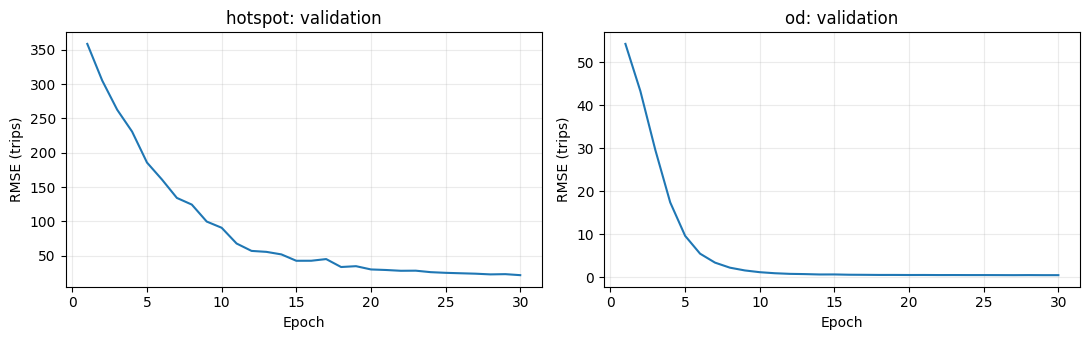

In [37]:
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(11,3.5))
for ax,name in zip(axes,['hotspot','od']):
    log=pd.read_csv(OUTPUT/f'{name}_validation.csv')
    ax.plot(log.epoch,log.validation_RMSE)
    ax.set(title=f'{name}: validation',xlabel='Epoch',ylabel='RMSE (trips)')
    ax.grid(alpha=.25)
plt.tight_layout(); plt.show(); plt.close(fig)
